# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [2]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [3]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [47]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.fc3 = nn.Linear(h2, out_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        return x


In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)


In [48]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            preds = model(xb)

            loss = loss_fn(preds, yb)

            loss.backward()

            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"epoch {ep}/{epochs} | train mse: {avg_loss:.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

train_part1(model, train_loader_1, epochs=EPOCHS)

epoch 1/1000 | train mse: 0.101782
epoch 500/1000 | train mse: 0.102073
epoch 1000/1000 | train mse: 0.101312


In [49]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.9458    0.7261    0.8215      2377
           C     0.9910    0.9213    0.9549      2263
           B     0.9463    0.9624    0.9543      3057
           A     0.9794    0.9806    0.9800      3144

   micro avg     0.9656    0.9073    0.9356     10841
   macro avg     0.9656    0.8976    0.9277     10841
weighted avg     0.9651    0.9073    0.9327     10841
 samples avg     0.6665    0.6437    0.6496     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[3026   99]
 [ 651 1726]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3220   19]
 [ 178 2085]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2278  167]
 [ 115 2942]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2293   65]
 [  61 3083]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.9394    0.7154    0.8123      1019
           C     0.9845    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _

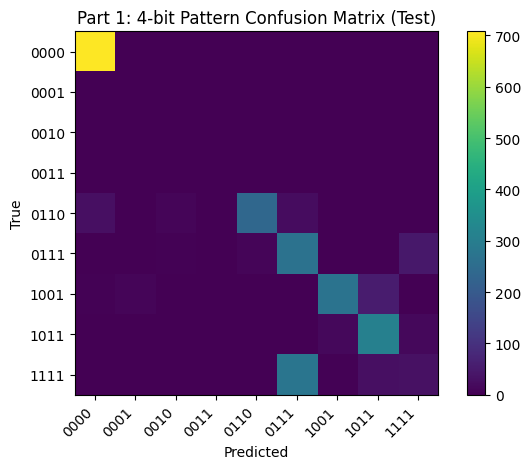

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 30   0  10   0 237  24   0   0   0]
 [  0   0   5   0  10 268   0   0  46]
 [  5  10   0   0   0   0 269  55   0]
 [  0   0   0   1   0   0  16 309  14]
 [  0   0   0   0   0 274   4  29  33]]


In [50]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [51]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [52]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.fc3 = nn.Linear(h2, out_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        logits = self.fc3(x)
        return logits


In [53]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model2 = DNN_MultiLabel4().to(device)

loss_fn2 = nn.BCEWithLogitsLoss()

optimizer2 = torch.optim.Adam(
    model2.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)


In [54]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer2.zero_grad()

            # forward pass (logits)
            logits = model(xb)

            # loss on logits
            loss = loss_fn2(logits, yb)

            # backward + step
            loss.backward()
            optimizer2.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"epoch {ep}/{epochs} | train bce: {avg_loss:.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

train_part2(model2, train_loader_2, epochs=EPOCHS)

epoch 1/1000 | train bce: 0.729663
epoch 500/1000 | train bce: 0.205291
epoch 1000/1000 | train bce: 0.200495


In [55]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model2, X_train_s2)
pred_bits_test_  = predict_bits_part2(model2, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.9697    0.7009    0.8137      2377
           C     1.0000    0.9085    0.9521      2263
           B     0.9979    0.9307    0.9631      3057
           A     1.0000    0.9682    0.9838      3144

   micro avg     0.9940    0.8865    0.9372     10841
   macro avg     0.9919    0.8771    0.9282     10841
weighted avg     0.9928    0.8865    0.9341     10841
 samples avg     0.6807    0.6319    0.6511     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[3073   52]
 [ 711 1666]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3239    0]
 [ 207 2056]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2439    6]
 [ 212 2845]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2358    0]
 [ 100 3044]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.9615    0.6860    0.8007      1019
           C     1.0000    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _

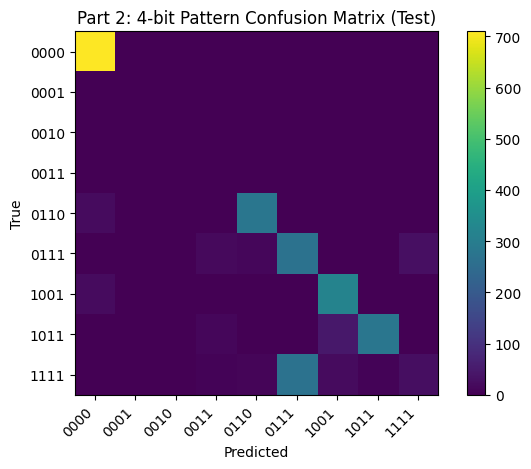

[[710   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 20   0   2   0 279   0   0   0   0]
 [  0   0   0  19  13 269   0   0  28]
 [ 20   1   0   0   0   0 318   0   0]
 [  1   1   0  12   0   0  47 279   0]
 [  0   0   0   7  10 268  22   8  25]]


In [56]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [57]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [ ]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.fc3 = nn.Linear(h2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        logits = self.fc3(x)
        return logits


In [59]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model3 = DNN_MultiClass6().to(device)

loss_fn3 = nn.CrossEntropyLoss()

optimizer3 = torch.optim.Adam(
    model3.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [60]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer3.zero_grad()

            logits = model(xb)

            loss = loss_fn3(logits, yb)

            loss.backward()
            optimizer3.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"epoch {ep}/{epochs} | train ce: {avg_loss:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

train_part3(model3, train_loader_3, epochs=EPOCHS)


epoch 1/1000 | train ce: 1.826865
epoch 500/1000 | train ce: 0.644322
epoch 1000/1000 | train ce: 0.632371



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9490    1.0000    0.9738      1655
          LG     0.8780    0.9114    0.8944       790
          LL     0.9045    0.9431    0.9234       703
         LLG     0.8682    0.9207    0.8936       794
         LLL     0.5510    0.4576    0.5000       767
        LLLG     0.5096    0.4666    0.4872       793

    accuracy                         0.8161      5502
   macro avg     0.7767    0.7832    0.7787      5502
weighted avg     0.8026    0.8161    0.8082      5502



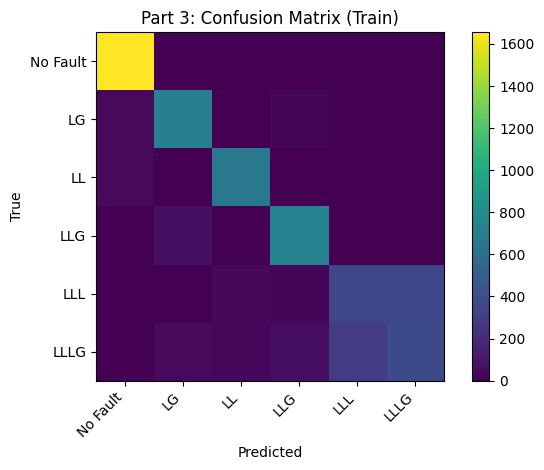


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9441    1.0000    0.9713       710
          LG     0.8789    0.9204    0.8991       339
          LL     0.9129    0.9402    0.9264       301
         LLG     0.8974    0.9265    0.9117       340
         LLL     0.4945    0.4103    0.4485       329
        LLLG     0.4780    0.4471    0.4620       340

    accuracy                         0.8084      2359
   macro avg     0.7676    0.7741    0.7698      2359
weighted avg     0.7942    0.8084    0.8003      2359



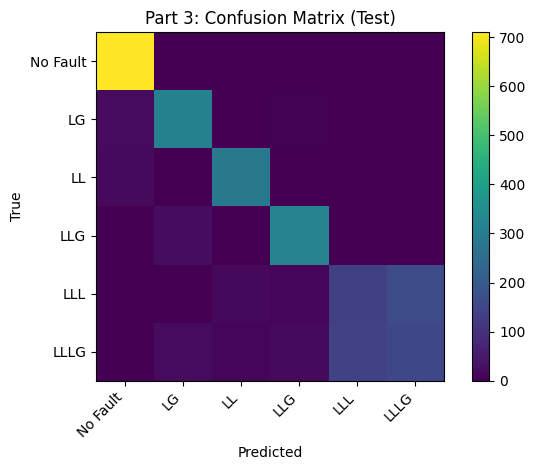

In [62]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model3, X_train_s3)
pred_test  = predict_part3(model3, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: The multi-label model fits this dataset best. The labels are naturally 4 separate bits, so predicting each bit directly matches the problem structure. It gave higher F1 scores than the regression model and much higher accuracy than the multi-class model. The multi-class model lost useful structure when the 4 bits were collapsed into 6 flat classes.

- Q2: Yes, some invalid 4-bit patterns appeared when using the bit-based models. This shows that the model predicts each bit independently and does not enforce physical rules about valid fault combinations. It suggests that extra constraints or post-processing could improve consistency.

- Q3: The G bit and the LLLG fault type were the hardest to predict. They had lower recall and F1 scores than other bits and classes. A likely reason is that ground-related faults may look similar to non-ground faults in the input measurements, making them harder to separate.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


binary counts (all): {0: np.int64(2365), 1: np.int64(5496)}
train size: 5502 | test size: 2359
epoch 1/1000 | train bce: 0.716940
epoch 500/1000 | train bce: 0.079638
epoch 1000/1000 | train bce: 0.063845

=== Part 5 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9572    0.9994    0.9778      1655
       Fault     0.9997    0.9808    0.9902      3847

    accuracy                         0.9864      5502
   macro avg     0.9785    0.9901    0.9840      5502
weighted avg     0.9869    0.9864    0.9865      5502



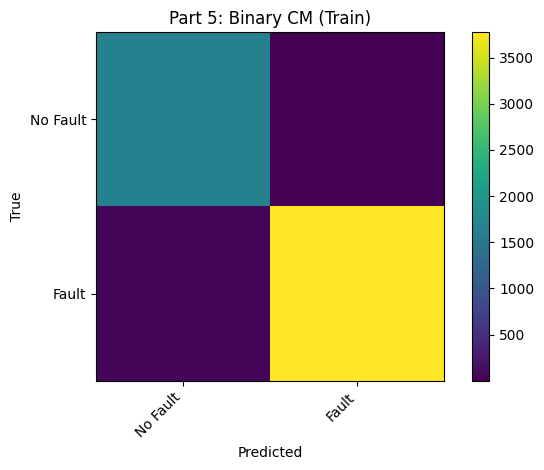

train cm:
 [[1654    1]
 [  74 3773]]

=== Part 5 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9647    1.0000    0.9820       710
       Fault     1.0000    0.9842    0.9921      1649

    accuracy                         0.9890      2359
   macro avg     0.9823    0.9921    0.9870      2359
weighted avg     0.9894    0.9890    0.9890      2359



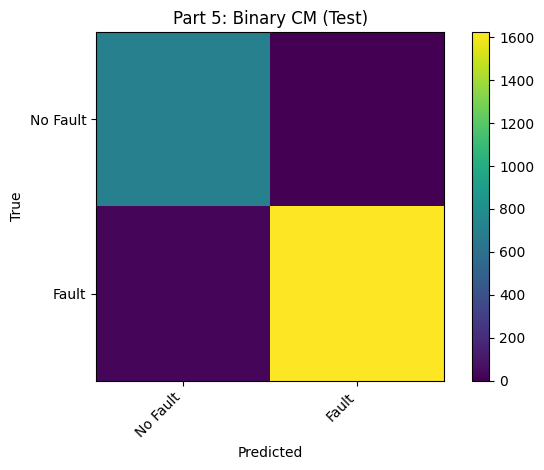

test cm:
 [[ 710    0]
 [  26 1623]]


In [63]:
y_bin = (Y_bits.sum(axis=1) != 0).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_bin, test_size=0.30, random_state=RANDOM_STATE, stratify=y_bin
)

print("binary counts (all):", dict(zip([0,1], np.bincount(y_bin))))
print("train size:", X_train_b.shape[0], "| test size:", X_test_b.shape[0])

scaler_b = RobustScaler()
X_train_sb = scaler_b.fit_transform(X_train_b).astype(np.float32)
X_test_sb  = scaler_b.transform(X_test_b).astype(np.float32)

Xtrb = torch.from_numpy(X_train_sb)
Xteb = torch.from_numpy(X_test_sb)
ytrb = torch.from_numpy(y_train_b.astype(np.float32)).view(-1, 1)  # (N,1)
yteb = torch.from_numpy(y_test_b.astype(np.float32)).view(-1, 1)

train_loader_b = DataLoader(
    TensorDataset(Xtrb, ytrb),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# model: 6 -> 16 -> 8 -> 1
class DNN_Binary(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.fc3 = nn.Linear(h2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        return self.fc3(x)

model_b = DNN_Binary().to(device)
loss_fn_b = nn.BCEWithLogitsLoss()
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

def train_part5(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_b.zero_grad()
            logits = model(xb)
            loss = loss_fn_b(logits, yb)
            loss.backward()
            optimizer_b.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"epoch {ep}/{epochs} | train bce: {avg_loss:.6f}")

@torch.no_grad()
def predict_part5(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
    preds = (probs >= threshold).astype(int)
    return preds

train_part5(model_b, train_loader_b, epochs=EPOCHS)

pred_train_b = predict_part5(model_b, X_train_sb)
pred_test_b  = predict_part5(model_b, X_test_sb)

print("\n=== Part 5 | Train ===")
print(classification_report(y_train_b, pred_train_b, target_names=["No Fault", "Fault"], digits=4))
cm_train_b = confusion_matrix(y_train_b, pred_train_b, labels=[0, 1])
plot_cm(cm_train_b, "Part 5: Binary CM (Train)", ["No Fault", "Fault"])
print("train cm:\n", cm_train_b)

print("\n=== Part 5 | Test ===")
print(classification_report(y_test_b, pred_test_b, target_names=["No Fault", "Fault"], digits=4))
cm_test_b = confusion_matrix(y_test_b, pred_test_b, labels=[0, 1])
plot_cm(cm_test_b, "Part 5: Binary CM (Test)", ["No Fault", "Fault"])
print("test cm:\n", cm_test_b)